**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Activity 4.1.4 Comparing optimisers

## Objective
Build a neural network model that predicts survivors of the Titanic voyage using data from the Titanic data set. Create and train the model with Adam and then RMSProp, and evaluate it to see which optimiser was most effective.

## Assessment criteria
By completing this activity, you'll be able to provide evidence that you can:
- load a data set for training a neural network model
- perform relevant preprocessing steps and split the data
- define a function to create and train a neural network model
- interpret model output and explain your conclusions
- select the appropriate model and justify your choice.

## Activity guidance
1. Import the relevant libraries and load the Titanic data set.
2. Complete data pre-processing, including dropping irrelevant columns and converting categorical data to binary values.
3. Fill in any missing values in the remaining columns.
4. Define features and a target variable.
5. Split the data into training and test sets.
5. Standardise features.
7. Define a function to create and train a neural network with:
  - One input layer of a number of neurons equal to the number of input features
  - One hidden layer
  - ReLU activations in every layer except the output layer, where you will use Sigmoid
  - Binary cross entropy as loss
  - Optimiser as the parameter of the function
8. Create and train models with Adam.
9. Create and train models with RMSProp.
10. Evaluate the models.


## Recording your method
As you prepare the data and build your models, make notes about the decisions you make. You may wish to record these comments in your Notebook, either beside the code, or in your reflection space at the end.

> Start your activity here. Select the pen from the toolbar to add your entry.

In [96]:
# Import the relevant libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop


In [97]:
# Load the Titanic data set.
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

print(titanic_df.shape)
print("\n")
titanic_df.info()
print("\n")
titanic_df.head()

(891, 12)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [98]:
# Drop irrelevant columns
titanic_df = titanic_df.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)
titanic_df.info()
print("\n")
titanic_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
dtypes: float64(2), int64(5), object(1)
memory usage: 55.8+ KB




,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [99]:
# Impute the values for Age using mean
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df.isnull().sum()

titanic_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [100]:
# Convert categorical column to binary/numeric
titanic_df['Sex'] = titanic_df['Sex'].map({ 'male': 0, 'female': 1})
titanic_df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833
2,3,1,3,1,26.0,0,0,7.9250
3,4,1,1,1,35.0,1,0,53.1000
4,5,0,3,0,35.0,0,0,8.0500


In [101]:
# Define features and a target variable
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

X.info()
print("\n")
X.head()

# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=100)

# Standardise features.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB




In [102]:
# One input layer of a number of neurons equal to the number of input features
# One hidden layer
# ReLU activations in every layer except the output layer, where you will use Sigmoid
# Binary cross entropy as loss
# Optimiser as the parameter of the function

def create_model(optimizer):
    model = Sequential()
    model.add(Input(shape=(7,))) # Input layer
    model.add(Dense(units=12, activation='relu')) # Hidden layer
    model.add(Dense(units=8, activation='relu')) # Hidden layer
    model.add(Dense(units=1, activation='sigmoid')) # Output layer

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [103]:
# Train the model with an Adam optimiser.
adam_model = create_model(optimizer=keras.optimizers.Adam(learning_rate=0.002)) # 'adam')
adam_history = adam_model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2, verbose=0)

# Train the model with an RMSProp optimiser.
rmsprop_model = create_model(optimizer=keras.optimizers.RMSprop(learning_rate=0.002) ) #'rmsprop')
rmsprop_history = rmsprop_model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2, verbose=0)

In [104]:
# Evaluate the models.
adam_test_loss, adam_test_acc = adam_model.evaluate(X_test, y_test)
rmsprop_test_loss, rmsprop_test_acc = rmsprop_model.evaluate(X_test, y_test)

print('\nAdam optimizer:')
print('Test loss:', adam_test_loss)
print('Test accuracy:', adam_test_acc)

print('\nRMSprop optimizer:')
print('Test loss:', rmsprop_test_loss)
print('Test accuracy:', rmsprop_test_acc)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8067 - loss: 0.4841  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7741 - loss: 0.5103  

Adam optimizer:
Test loss: 0.44932761788368225
Test accuracy: 0.826815664768219

RMSprop optimizer:
Test loss: 0.47318950295448303
Test accuracy: 0.7821229100227356


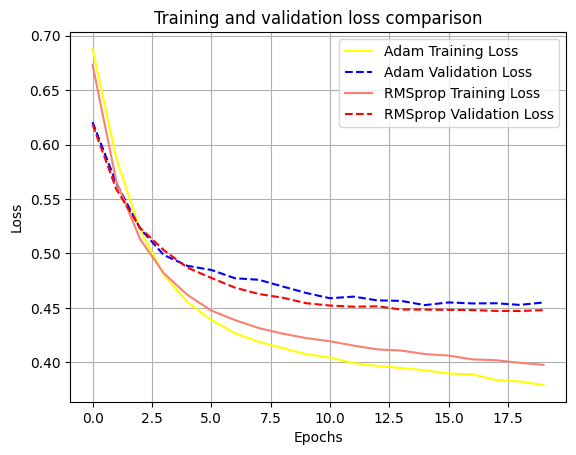

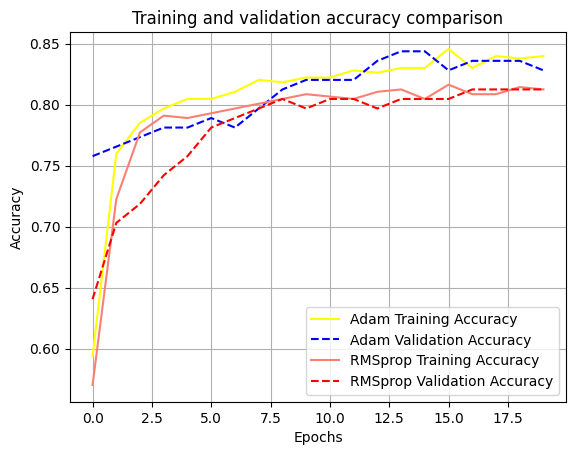

In [106]:
# Plot loss
#plt.figure(figsize=(12, 6))
plt.plot(adam_history.history['loss'], label='Adam Training Loss', color='yellow')
plt.plot(adam_history.history['val_loss'], label='Adam Validation Loss', color='blue', linestyle='--')
plt.plot(rmsprop_history.history['loss'], label='RMSprop Training Loss', color='salmon')
plt.plot(rmsprop_history.history['val_loss'], label='RMSprop Validation Loss', color='red', linestyle='--')
plt.title('Training and validation loss comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy.
#plt.figure(figsize=(12, 6))
plt.plot(adam_history.history['accuracy'], label='Adam Training Accuracy', color='yellow')
plt.plot(adam_history.history['val_accuracy'], label='Adam Validation Accuracy', color='blue', linestyle='--')
plt.plot(rmsprop_history.history['accuracy'], label='RMSprop Training Accuracy', color='salmon')
plt.plot(rmsprop_history.history['val_accuracy'], label='RMSprop Validation Accuracy', color='red', linestyle='--')
plt.title('Training and validation accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Reflect

Summarise the decisions you made when preparing the data and building the models.

Interpret the model output, and state your conclusions comparing the performance of Adam and RMSProp.

What makes this experiment a valid comparison of the two optimisers? Explain why the observed effects can be attributed to the optimisers. If you perform the experiment repeatedly, what kind of variation would you expect in your results?

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Select the pen from the toolbar to add your entry.

# Activity 4.2.4 Implementing regularisation techniques

## Objective
Using the neural network model you built above, modify the ‘create_model’ function to include dropout and L2 regularisation.

## Assessment criteria
By completing this activity, you will be able to provide evidence that you can:
- define a function to create and train a neural network model
- interpret model output and explain your conclusions
- select the appropriate model and justify your choice.

## Activity steps
1. Import the L2 regulariser and dropout.
3. Run a model function with dropout and regularisation included.
4. Create and train a model with Adam optimisation, l2 regularisation and dropout.
5. Create and train a model with RMSProp optimisation, l2 regularisation and dropout.
6. Plot model accuracy and loss.
7. Evaluate the models.


In [107]:
# Import the regulariser and dropout.
from keras.regularizers import l2
from keras.layers import Dense, Dropout

In [108]:
# Define a function to create and compile the model.
def create_model_reg(optimizer=None, regularization=None, dropout_rate=None):
    model = Sequential()
    model.add(Dense(64, activation='relu', kernel_regularizer=regularization))
    model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu', kernel_regularizer=regularization))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

#### Create and train model with Adam optimization, L2 regularisation and dropout

In [109]:
adam_model_reg = create_model_reg(optimizer=keras.optimizers.Adam(learning_rate=0.001), regularization=l2(0.01), dropout_rate=0.2)
adam_history_reg = adam_model_reg.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2, verbose=0)

#### Create and train a model with RMSProp optimisation, l2 regularisation and dropout.

In [110]:
rmsprop_model_reg = create_model_reg(optimizer=keras.optimizers.RMSprop(learning_rate=0.001), regularization=l2(0.01), dropout_rate=0.2)
rmsprop_history_reg = rmsprop_model_reg.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2, verbose=0)

#### Plot model accuracy and loss.

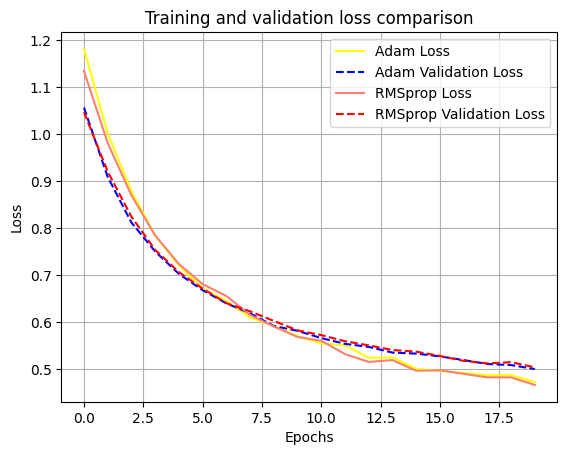

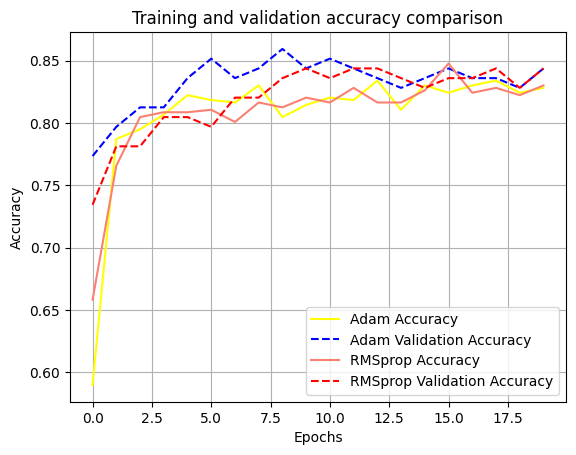

In [111]:
# Plot loss
# plt.figure(figsize=(12, 6))
plt.plot(adam_history_reg.history['loss'], label='Adam Loss', color='yellow')
plt.plot(adam_history_reg.history['val_loss'], label='Adam Validation Loss', color='blue', linestyle='--')
plt.plot(rmsprop_history_reg.history['loss'], label='RMSprop Loss', color='salmon')
plt.plot(rmsprop_history_reg.history['val_loss'], label='RMSprop Validation Loss', color='red', linestyle='--')
plt.title('Training and validation loss comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy.
# plt.figure(figsize=(12, 6))
plt.plot(adam_history_reg.history['accuracy'], label='Adam Accuracy', color='yellow')
plt.plot(adam_history_reg.history['val_accuracy'], label='Adam Validation Accuracy', color='blue', linestyle='--')
plt.plot(rmsprop_history_reg.history['accuracy'], label='RMSprop Accuracy', color='salmon')
plt.plot(rmsprop_history_reg.history['val_accuracy'], label='RMSprop Validation Accuracy', color='red', linestyle='--')
plt.title('Training and validation accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#### Evaluate the models.

In [112]:
adam_reg_loss, adam_reg_acc = adam_model_reg.evaluate(X_test, y_test)
rmsprop_reg_loss, rmsprop_reg_acc = rmsprop_model_reg.evaluate(X_test, y_test)

print('\nAdam optimizer:')
print('Test loss:', adam_reg_loss)
print('Test accuracy:', adam_reg_acc)

print('\nRMSprop optimizer:')
print('Test loss:', rmsprop_reg_loss)
print('Test accuracy:', rmsprop_reg_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7919 - loss: 0.5288  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7950 - loss: 0.5337  

Adam optimizer:
Test loss: 0.5055726170539856
Test accuracy: 0.8044692873954773

RMSprop optimizer:
Test loss: 0.509745180606842
Test accuracy: 0.8156424760818481


# Reflect

Interpret the model output, and state your conclusions on model performance using Adam, RMSProp, L2 regularisation, and dropout.

What makes this experiment a valid comparison of the two regularisation approaches? Explain why the observed effects can be attributed to the regularisation techniques. If you perform the experiment repeatedly, what kind of variation would you expect in your results?

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Select the pen from the toolbar to add your entry.

# Activity 4.3.3 Implementing early stopping

## Objective
Building on the neural network model, add early stopping callbacks on models trained with Adam and RMSProp.

## Assessment criteria
By completing this activity, you will be able to provide evidence that you can:
- define a function to create and train a neural network model
- interpret model output and explain your conclusions
- select the appropriate model and justify your choice.

## Activity steps
1. Import early stopping from Keras.
3. Add early stopping to a model trained with Adam optimisation that includes the following parameters:
- patience = 1
- lr=0.001
- L2 regularisation of 0.01.
4. Add early stopping to a model trained with RMSProp optimisation that includes the same parameters.
5. Plot model accuracy and loss.
6. Evaluate the models.

In [113]:
# Import early stopping
from keras.callbacks import EarlyStopping

In [114]:
# Run Adam with call back
adam_model_reg_callback = create_model_reg(optimizer=keras.optimizers.Adam(learning_rate=0.001), regularization=l2(0.01), dropout_rate=0.2)
adam_early_stopping = EarlyStopping(monitor='val_loss', patience=1, verbose=1, mode='min', restore_best_weights=True)
adam_history_callback_history = adam_model_reg_callback.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0, callbacks=[adam_early_stopping])

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 20.


In [115]:
# Run RMSprop model with callback
rmsprop_model_reg_callback = create_model_reg(optimizer=keras.optimizers.RMSprop(learning_rate=0.001), regularization=l2(0.01), dropout_rate=0.2)
rmsprop_early_stopping = EarlyStopping(monitor='val_loss', patience=1, verbose=1, mode='min', restore_best_weights=True)
rmsprop_reg_callback_history = rmsprop_model_reg_callback.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0, callbacks=[rmsprop_early_stopping])

Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 18.


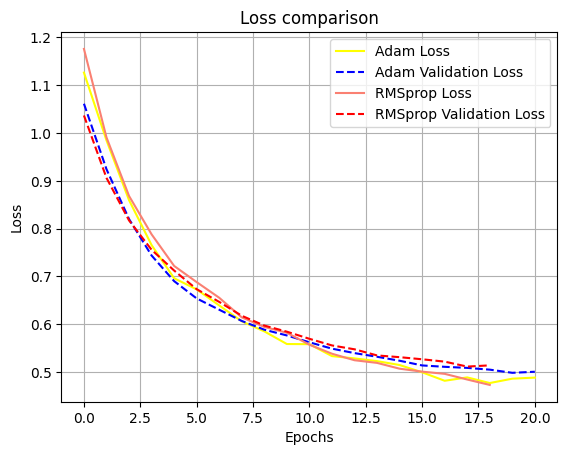

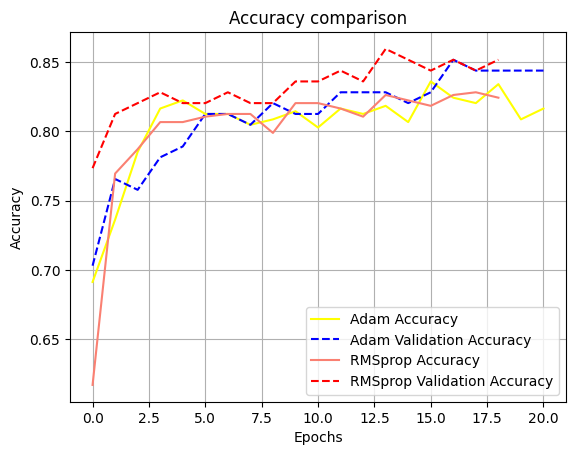

In [116]:
# Plot loss
# plt.figure(figsize=(12, 6))
plt.plot(adam_history_callback_history.history['loss'], label='Adam Loss', color='yellow')
plt.plot(adam_history_callback_history.history['val_loss'], label='Adam Validation Loss', color='blue', linestyle='--')
plt.plot(rmsprop_reg_callback_history.history['loss'], label='RMSprop Loss', color='salmon')
plt.plot(rmsprop_reg_callback_history.history['val_loss'], label='RMSprop Validation Loss', color='red', linestyle='--')
plt.title('Loss comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy.
# plt.figure(figsize=(12, 6))
plt.plot(adam_history_callback_history.history['accuracy'], label='Adam Accuracy', color='yellow')
plt.plot(adam_history_callback_history.history['val_accuracy'], label='Adam Validation Accuracy', color='blue', linestyle='--')
plt.plot(rmsprop_reg_callback_history.history['accuracy'], label='RMSprop Accuracy', color='salmon')
plt.plot(rmsprop_reg_callback_history.history['val_accuracy'], label='RMSprop Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate the model

In [117]:
adam_reg_callback_loss, adam_reg_callback_acc = adam_model_reg_callback.evaluate(X_test, y_test)
rmsprop_reg_callback_loss, rmsprop_reg_callback_acc = rmsprop_model_reg_callback.evaluate(X_test, y_test)

print('\nAdam optimizer:')
print('Test loss:', adam_reg_callback_loss)
print('Test accuracy:', adam_reg_callback_acc)

print('\nRMSprop optimizer:')
print('Test loss:', rmsprop_reg_callback_loss)
print('Test accuracy:', rmsprop_reg_callback_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7913 - loss: 0.5322  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7970 - loss: 0.5454  

Adam optimizer:
Test loss: 0.5060111284255981
Test accuracy: 0.8156424760818481

RMSprop optimizer:
Test loss: 0.5182740688323975
Test accuracy: 0.8100558519363403


# Reflect

Interpret the model output, and state your conclusions on model performance using Adam, RMSProp,and dropout callbacks.

Explain why the observed effects can be attributed to the dropout callback. If you perform the experiment repeatedly, what kind of variation would you expect in your results?

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Select the pen from the toolbar to add your entry.